In [78]:
# 可视化CT数据实现

# simpleITK ipyvolume diskcache cassandra-driver

%pip install simpleITK ipyvolume diskcache cassandra-driver


Note: you may need to restart the kernel to use updated packages.


In [79]:
%pip install torch

Note: you may need to restart the kernel to use updated packages.


In [80]:
%matplotlib inline 

In [81]:

import gzip
from diskcache import FanoutCache, Disk
from cassandra.cqltypes import BytesType
from diskcache import FanoutCache, Disk, core
from diskcache.core import io
from io import BytesIO
from diskcache.core import  MODE_BINARY
from util.logconf import logging
log = logging.getLogger(__name__)
log.setLevel(logging.INFO)


import matplotlib
# matplotlib.use('nbagg')

import numpy as np
import matplotlib.pyplot as plt
import sys

from code1.dsets import Ct, LunaDataset

clim = (-1000.0, 300)
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # 添加到 Python 代码中
os.environ["OMP_NUM_THREADS"] = "4"   # 限制 OpenMP 线程数
os.environ["MKL_NUM_THREADS"] = "4"   # 限制 MKL 线程数
print("Matplotlib版本:", matplotlib.__version__)
print("后端配置:", matplotlib.get_backend())

Matplotlib版本: 3.9.2
后端配置: inline


In [82]:
def findPositiveSamples(start_ndx=0, limit=100):
    ds = LunaDataset()
    positiveSample_list = []
    for sample_tup in ds.candidateInfo_list:
        if sample_tup.isNodule_bool:
            print(len(positiveSample_list), sample_tup)
            positiveSample_list.append(sample_tup)
        if len(positiveSample_list) >= limit:
            break
    return positiveSample_list

In [83]:
def showCandidate(series_uid, batch_ndx=None, **kwargs):

    plt.close('all')  # 关闭之前的图形
    ds = LunaDataset(series_uid=series_uid, **kwargs)
    pos_list = [i for i , x in enumerate(ds.candidateInfo_list) if x.isNodule_bool]
    
    if batch_ndx is None:
        if pos_list:
            batch_ndx = pos_list[0]
        else:
            print("Warning : no positive samples found; using first negative sample.")
            batch_ndx = 0
            
    ct = Ct(series_uid)
    ct_t, pos_t, series_uid, center_irc = ds[batch_ndx]
    ct_a = ct_t[0].numpy()
    ct_a = np.clip(ct_a, -1000, 1000)  # 裁剪到标准 HU 范围

    print(f'cta_shape: {ct_a.shape}')
    print("ct_a 数据范围:", ct_a.min(), ct_a.max())

    # 验证数据有效性
    assert not np.isnan(ct_a).any(), "CT数据包含NaN值!"
    assert ct_a.size > 0, "CT数据为空!"

    # plt.figure(figsize=(5,5))
    # plt.imshow(ct_a[0], clim=clim, cmap='gray')  # 第 0 个切片
    # plt.colorbar()
    # plt.show()
    # return
        
    fig = plt.figure(figsize=(20, 25))

    
    group_list = [[5, 10, 15], [20, 25, 30], [8, 16, 24]]
    
    #add_subplot(3, 4, 9)
    subplot = fig.add_subplot(len(group_list) + 2, 3, 1)
    subplot.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct.hu_a[int(center_irc[0])], clim=clim, cmap='gray')
    
    
    subplot = fig.add_subplot(len(group_list) + 2, 3, 2)
    subplot.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct.hu_a[:,int(center_irc[1])], clim=clim, cmap='gray')#取行信息展示，对应我们的正视图
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 3)
    subplot.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt. imshow(ct.hu_a[:,:,int(center_irc[2])], clim=clim, cmap='gray')#取列信息展示，对应我们的侧视图
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 4)
    subplot.set_title('index {}'.format(int(center_irc[0])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[ct_a.shape[0]//2], clim=clim, cmap='gray')#这个是取候选小块的信息，除2是放大？

    subplot = fig.add_subplot(len(group_list) + 2, 3, 5)
    subplot.set_title('row {}'.format(int(center_irc[1])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[:,ct_a.shape[1]//2], clim=clim, cmap='gray')#候选小块的行信息
    plt.gca().invert_yaxis()

    subplot = fig.add_subplot(len(group_list) + 2, 3, 6)
    subplot.set_title('col {}'.format(int(center_irc[2])), fontsize=30)
    for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
        label.set_fontsize(20)
    plt.imshow(ct_a[:,:,ct_a.shape[2]//2], clim=clim, cmap='gray') #候选小块的列信息
    plt.gca().invert_yaxis()
    
    
    for row, index_list in enumerate(group_list):
        for col, index in enumerate(index_list):
            subplot_idx = row * 3 + col + 7
            subplot = fig.add_subplot(len(group_list) + 2, 3, subplot_idx)
            subplot.set_title('slice {}'.format(index), fontsize=30)
            for label in (subplot.get_xticklabels() + subplot.get_yticklabels()):
                label.set_fontsize(20)
            plt.imshow(ct_a[index], clim=clim, cmap='gray')
    plt.tight_layout()
    plt.show()
    #print(series_uid, batch_ndx, bool(pos_t[0]), pos_list)

In [84]:

from code1.vis import findPositiveSamples, showCandidate
positiveSample_list = findPositiveSamples()

2025-04-26 22:04:49,162 INFO     pid:10868 code1.dsets:176:__init__ <code1.dsets.LunaDataset object at 0x00000212E64C86E0>: 56938 training samples


0 CandidateInfoTuple(isNodule_bool=True, diameter_mm=5.654138498, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.313605260055394498989743099991', center_xyz=(-104.595743227, -65.0387901544, -152.824022564))
1 CandidateInfoTuple(isNodule_bool=True, diameter_mm=4.315291242, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.534083630500464995109143618896', center_xyz=(114.247666457, -37.1199002155, -138.729666881))
2 CandidateInfoTuple(isNodule_bool=True, diameter_mm=10.06186005, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.250863365157630276148828903732', center_xyz=(-83.1930640477, -29.0767194265, -153.227780712))
3 CandidateInfoTuple(isNodule_bool=True, diameter_mm=0.0, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.227962600322799211676960828223', center_xyz=(77.1171358377, -6.7515977048, -53.8551263442))
4 CandidateInfoTuple(isNodule_bool=True, diameter_mm=12.68580657, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.313334055029671473836954456733', center_xyz=(67.68450126, 44.02446338, -265

In [85]:
len(positiveSample_list)

100

In [90]:

series_uid = positiveSample_list[11][2]
showCandidate(series_uid)

2025-04-26 22:05:29,065 INFO     pid:10868 code1.dsets:176:__init__ <code1.dsets.LunaDataset object at 0x00000212EA98D370>: 508 training samples


1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059 118 False [118, 225, 357]


In [91]:
series_uid = positiveSample_list[11][2]
showCandidate(series_uid)

2025-04-26 22:05:33,709 INFO     pid:10868 code1.dsets:176:__init__ <code1.dsets.LunaDataset object at 0x00000212E6699880>: 508 training samples


1.3.6.1.4.1.14519.5.2.1.6279.6001.109002525524522225658609808059 23 False [23, 70, 101]


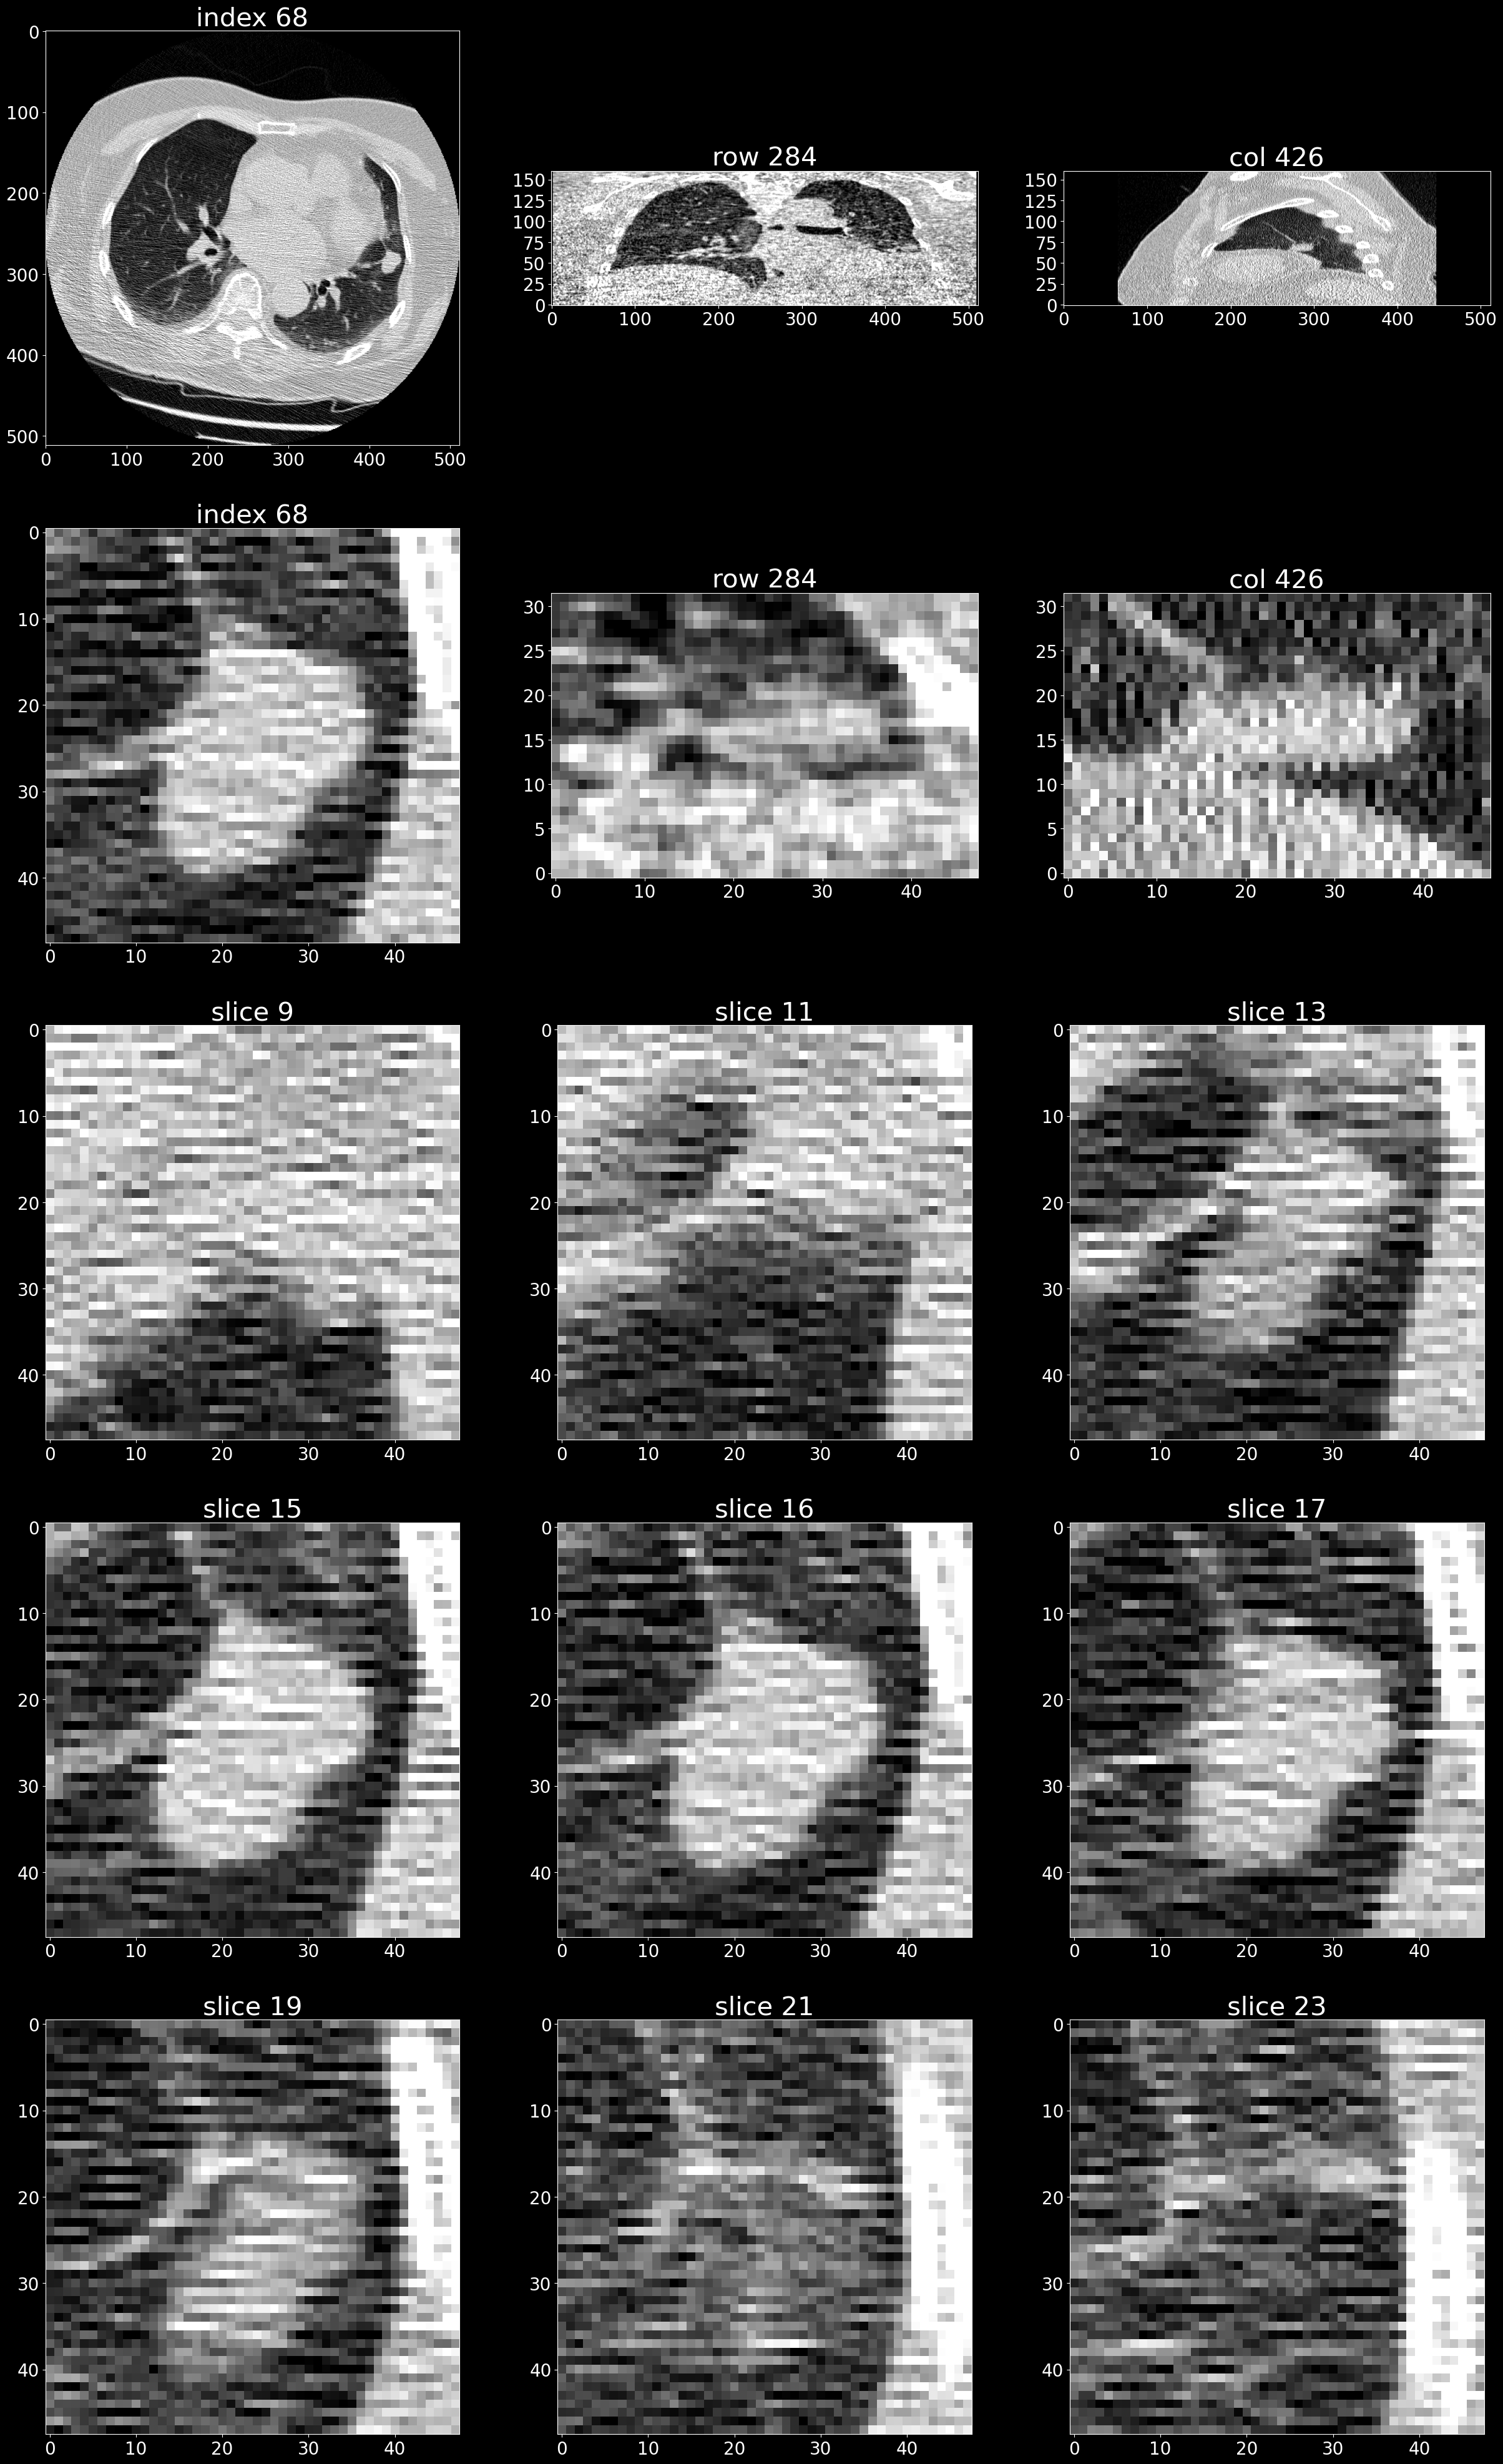

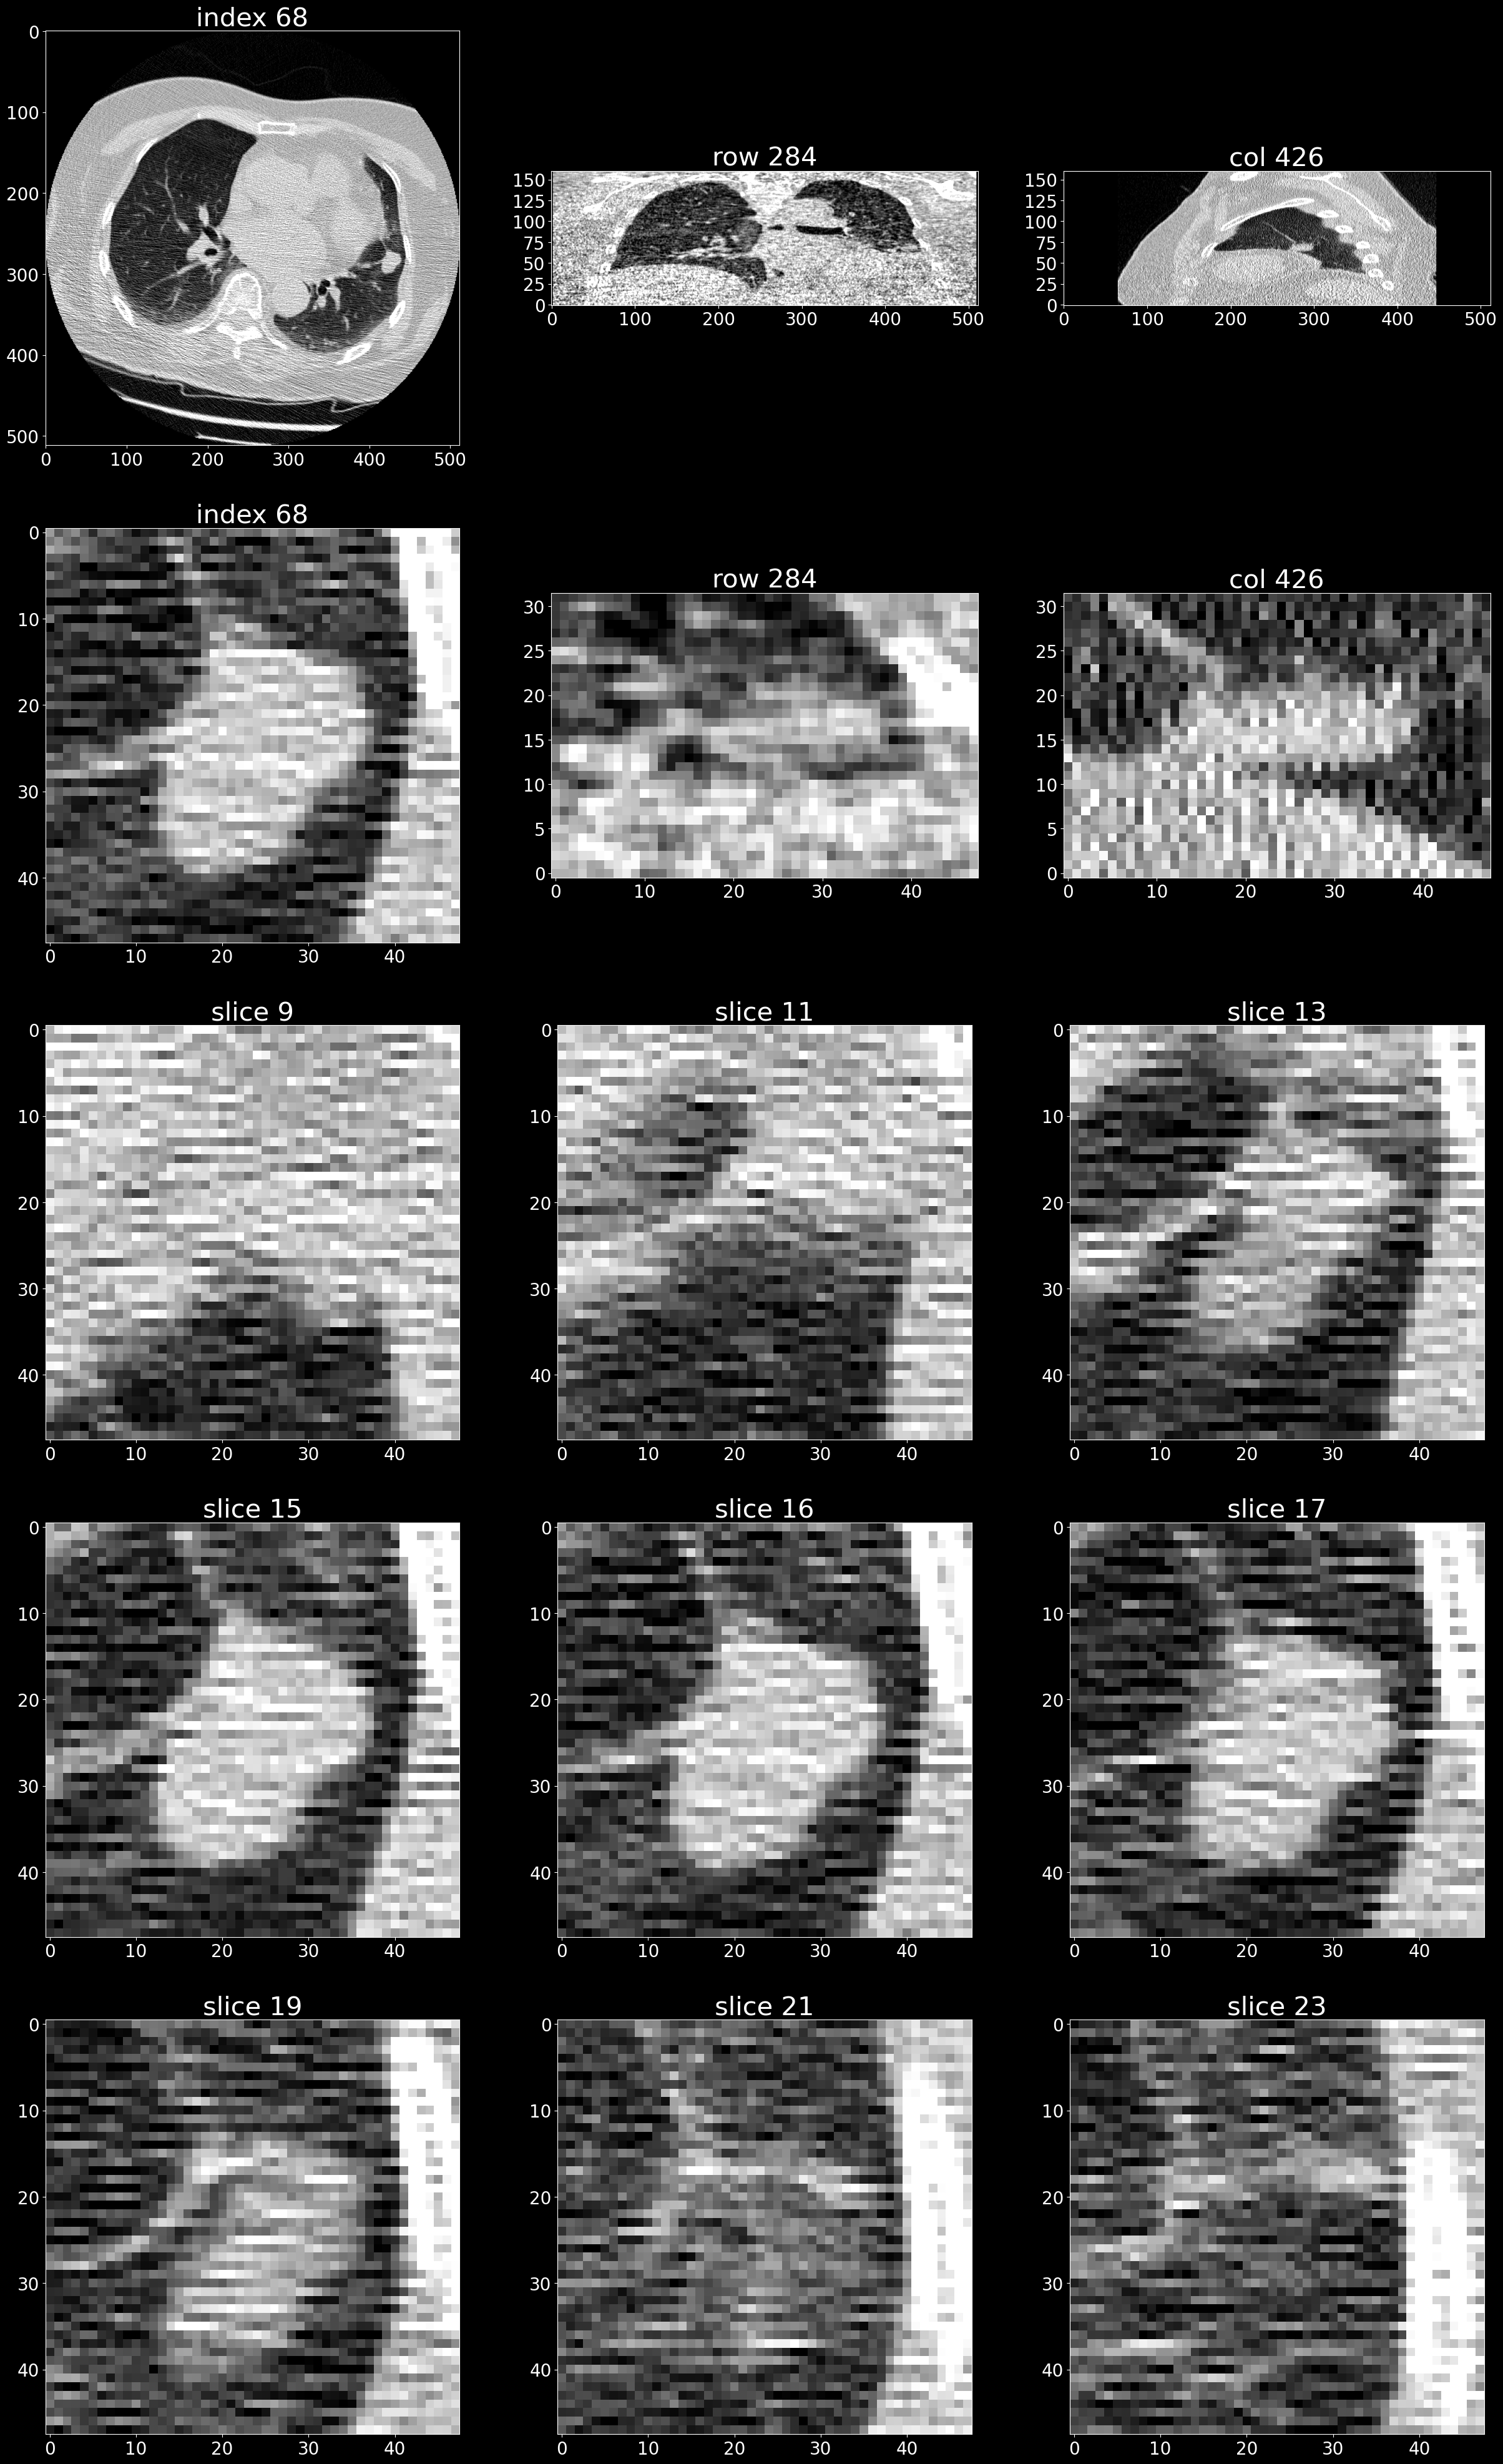

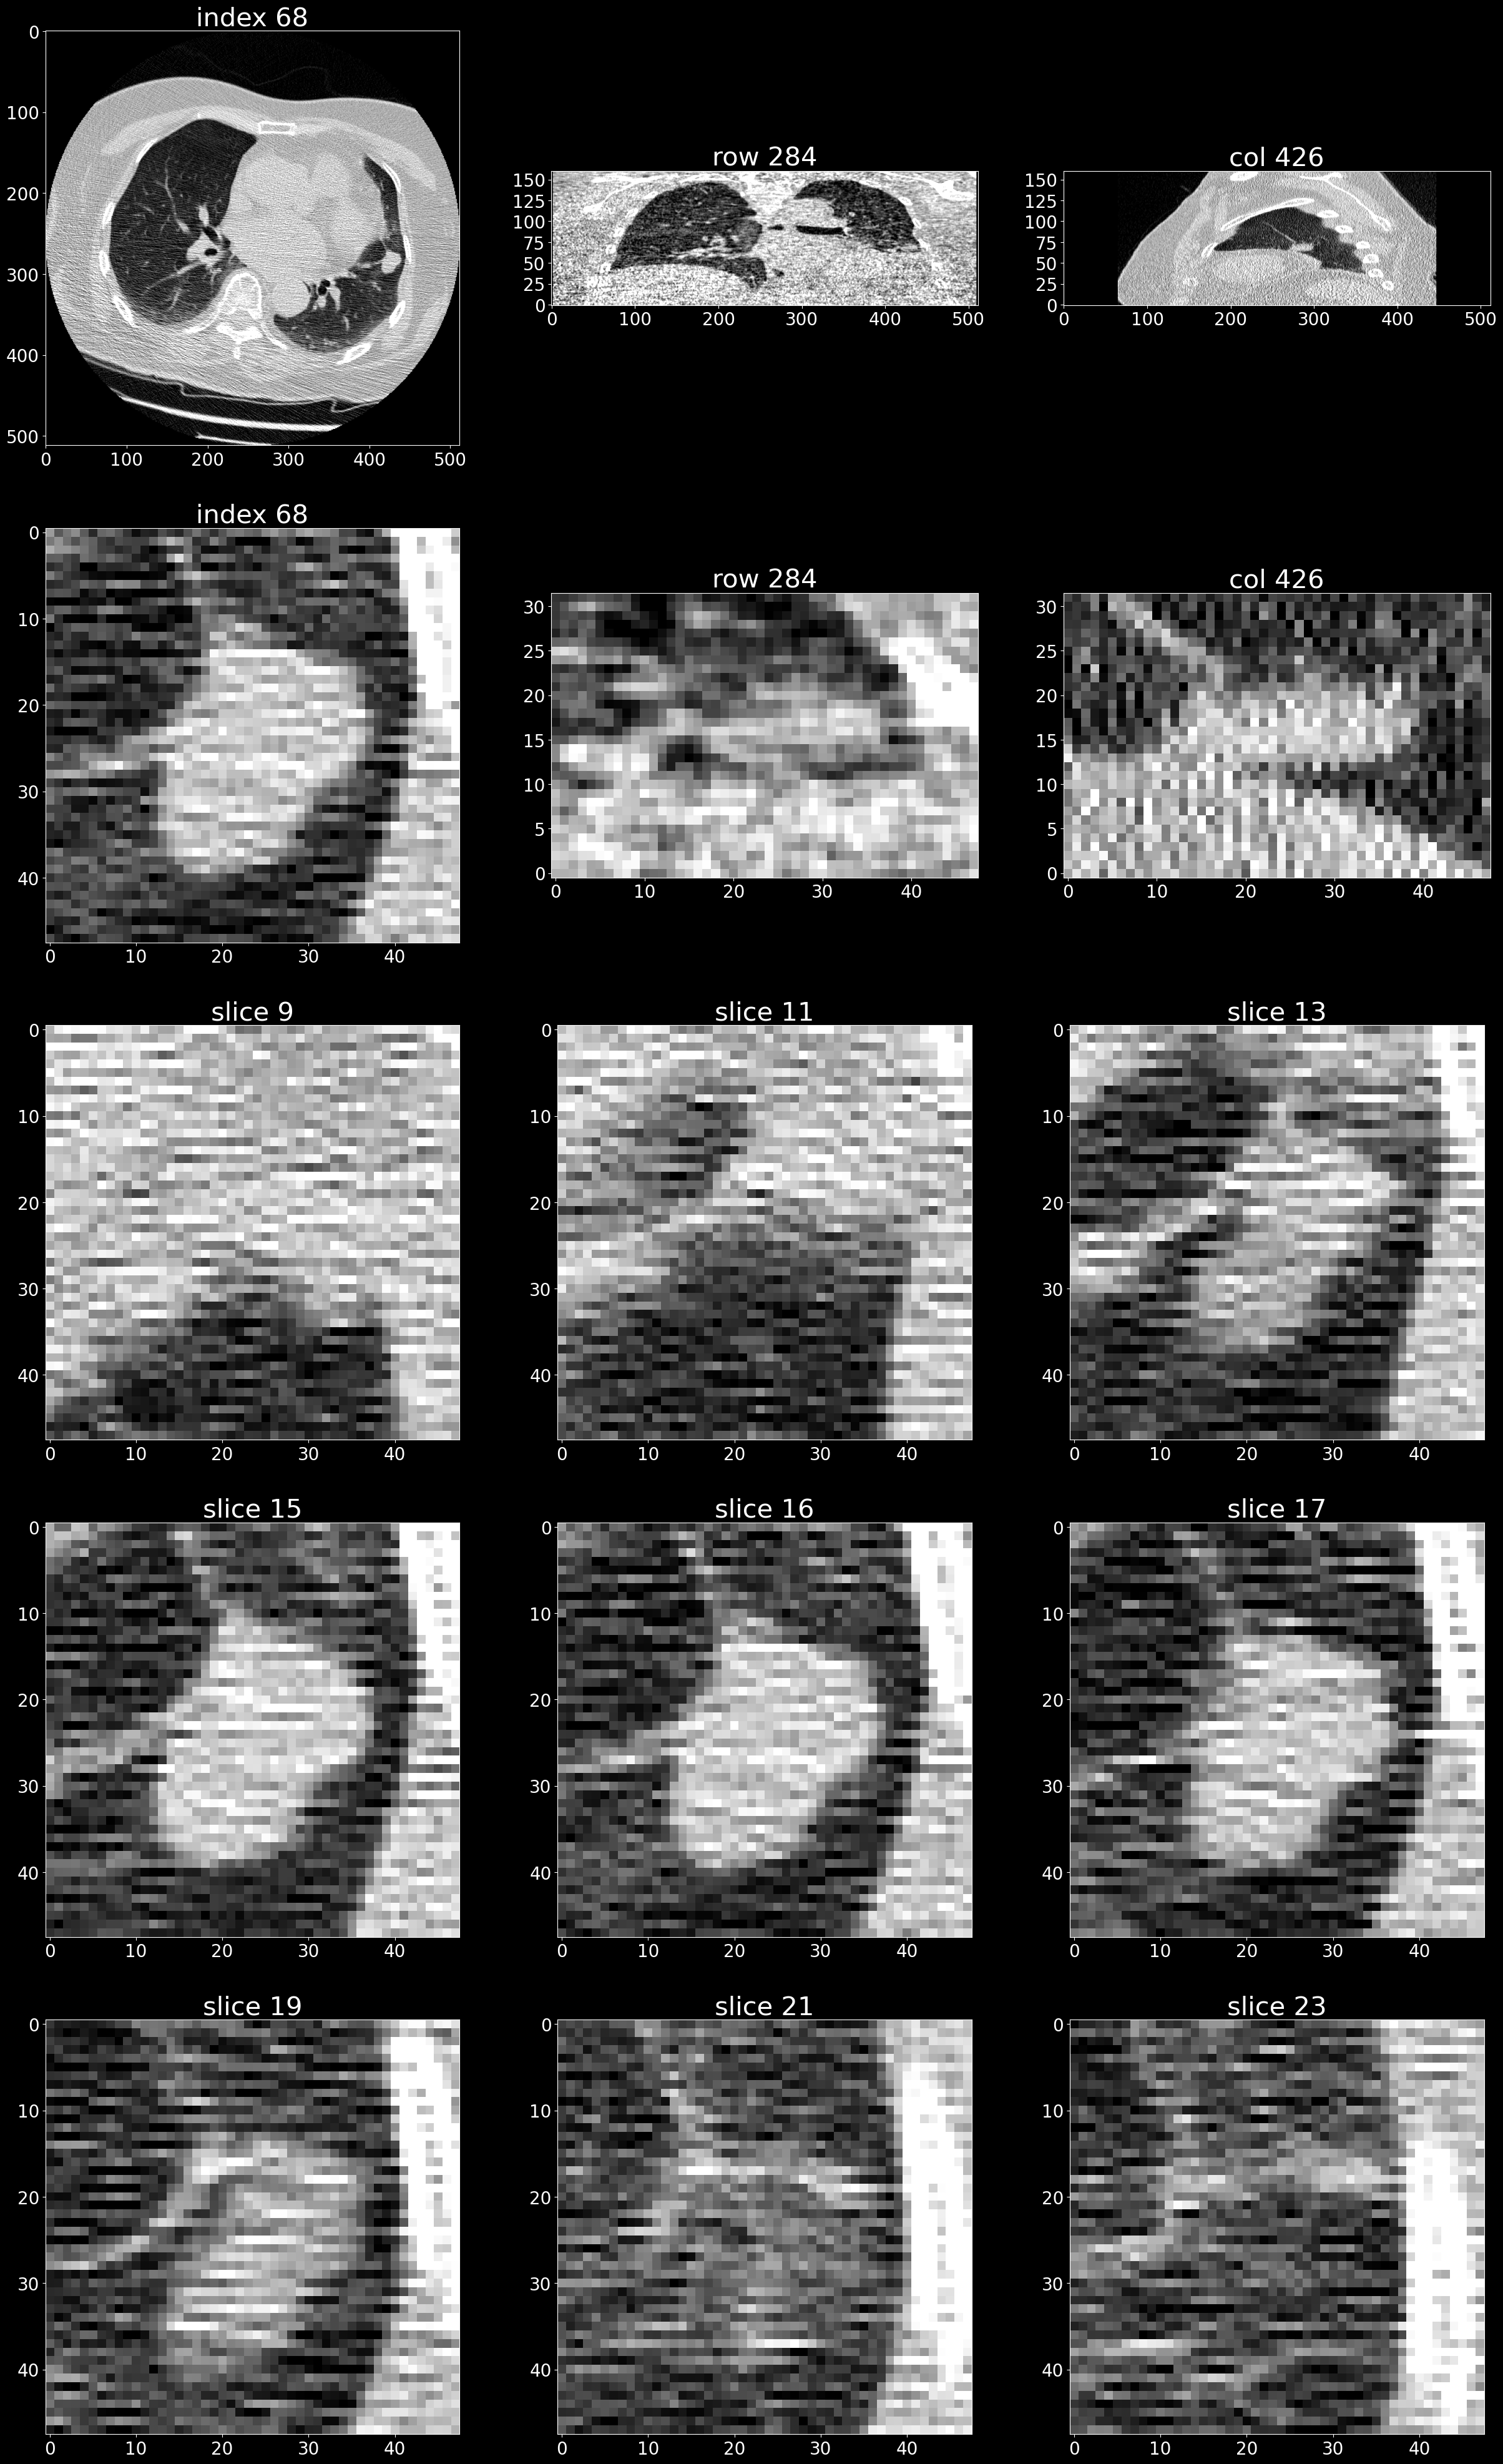

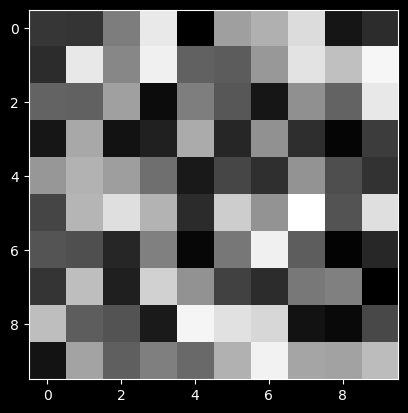

In [93]:
def test_plot():
    data = np.random.rand(10, 10)
    plt.figure()
    plt.imshow(data, cmap='gray')
    plt.show()

test_plot()